# ⚾ MLB 2020-2025 관중 수 예측 통합 분석 모델

이 노트북은 2020년부터 2024년까지의 MLB 경기 데이터를 활용하여 **2025년 시즌의 관중 수**를 예측하는 모델을 구축합니다.
KBO 관중 분석의 정교한 피처 엔지니어링(인기도, 모멘텀, 라이벌 매치)과 MLB의 도메인 지식(구장 규모, 티어)을 결합하여 분석을 진행합니다.

## 분석 흐름
1. **데이터 전처리**: 결측치 처리, 날짜 변환, 구장 정보 매핑
2. **피처 엔지니어링**: KBO 스타일의 인기도/최근 승률/라이벌 매치 생성
3. **EDA & 시각화**: 연도별/월별/요일별/구장별 관중 트렌드 분석
4. **모델링**: XGBoost, LightGBM, CatBoost를 결합한 **Voting Ensemble** 모델
5. **평가**: 2025년 실제 데이터와의 비교 및 시각화

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    # 나눔폰트가 설치되어 있어야 합니다.
    plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# Seaborn 테마 설정 (폰트 설정 후 적용해야 함)
sns.set_theme(style="whitegrid", font='Malgun Gothic', rc={"axes.unicode_minus": False})

## 1. 데이터 로드 및 Feature Engineering

In [12]:
# 1. 데이터 로드
df = pd.read_csv('mlb_game_log_2020_2025.csv')
df['경기일자'] = pd.to_datetime(df['경기일자'], format='%Y%m%d')
df = df.sort_values('경기일자').reset_index(drop=True)

# 2020년 관중수 결측치 처리 (팬데믹으로 인한 무관중 경기)
# 학습 시 노이즈를 줄이기 위해 0 또는 결측치는 이전 값으로 채우거나 0으로 명시
df['관중수'] = df['관중수'].fillna(0)

# 2. 구장 수용 인원 매핑 (MLB 주요 구장 정적 정보)
stadium_cap = {
    'LOS03': 56000, 'NYC21': 46537, 'NYC20': 41922, 'CHI11': 41649, 
    'CHI12': 40615, 'BOS07': 37755, 'LOS06': 45050, 'SAN02': 40209,
    'PHI13': 42792, 'STL10': 45494, 'ATL03': 41084, 'HOU03': 41168,
    'WAS11': 41339, 'ANA01': 45517, 'DEN02': 50398, 'SEA03': 47929,
    'SFO03': 41265, 'MIN04': 38544, 'MIL06': 41900, 'DET05': 41083,
    'CIN09': 42319, 'PIT08': 38362, 'KAN06': 37903, 'PHO01': 48519,
    'BAL12': 45971, 'TOR02': 49282, 'CLE08': 34788, 'OAK01': 46847,
    'STP01': 25000, 'MIA08': 36742, 'TEX05': 40300
}
df['Capacity'] = df['구장ID'].map(stadium_cap).fillna(40000)

# 3. 시간 변수 생성
df['연도'] = df['경기일자'].dt.year
df['월'] = df['경기일자'].dt.month
df['weekday'] = df['경기일자'].dt.weekday
df['주말'] = df['weekday'].isin([4, 5, 6]).astype(int) # 금, 토, 일
df['주야_encoded'] = df['주야경기구분'].map({'D': 0, 'N': 1}).fillna(1)

# 4. 성적 및 모멘텀 (KBO 스타일 적용)
# 홈팀 승리 여부 및 최근 10경기 승률
df['홈_승리'] = (df['홈팀점수'] > df['원정팀점수']).astype(float)
df['홈_최근10경기승률'] = df.groupby(['연도', '홈팀'])['홈_승리'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
).fillna(0.5)

df['시즌_진행률'] = df.groupby(['연도', '홈팀']).cumcount() / 81.0

# 5. 인기도 지표 (Leakage 방지: 경기 이전 시점까지의 누적 평균)
df['홈팀_인기도'] = df.groupby('홈팀')['관중수'].transform(lambda x: x.shift(1).expanding().mean())
df['원정팀_인기도'] = df.groupby('원정팀')['관중수'].transform(lambda x: x.shift(1).expanding().mean())
df['홈팀_인기도'] = df['홈팀_인기도'].fillna(df['관중수'].mean())
df['원정팀_인기도'] = df['원정팀_인기도'].fillna(df['관중수'].mean())

# 6. 라이벌 매치 설정
rivals = [
    ('NYA', 'BOS'), ('BOS', 'NYA'), # Yankees-Red Sox
    ('LAN', 'SFN'), ('SFN', 'LAN'), # Dodgers-Giants
    ('CHN', 'SLN'), ('SLN', 'CHN'), # Cubs-Cardinals
    ('NYA', 'NYN'), ('NYN', 'NYA'), # Subway Series
    ('CHA', 'CHN'), ('CHN', 'CHA'), # Windy City Showdown
    ('LAN', 'ANA'), ('ANA', 'LAN')  # Freeway Series
]
df['라이벌매치'] = df.apply(lambda row: int((row['홈팀'], row['원정팀']) in rivals), axis=1)

# 점유율 변수 (EDA용)
df['점유율'] = df['관중수'] / df['Capacity']

print(f"데이터 로드 및 피처 생성 완료. 전체 행 수: {len(df)}")

데이터 로드 및 피처 생성 완료. 전체 행 수: 13046


## 2. 상세 EDA 분석

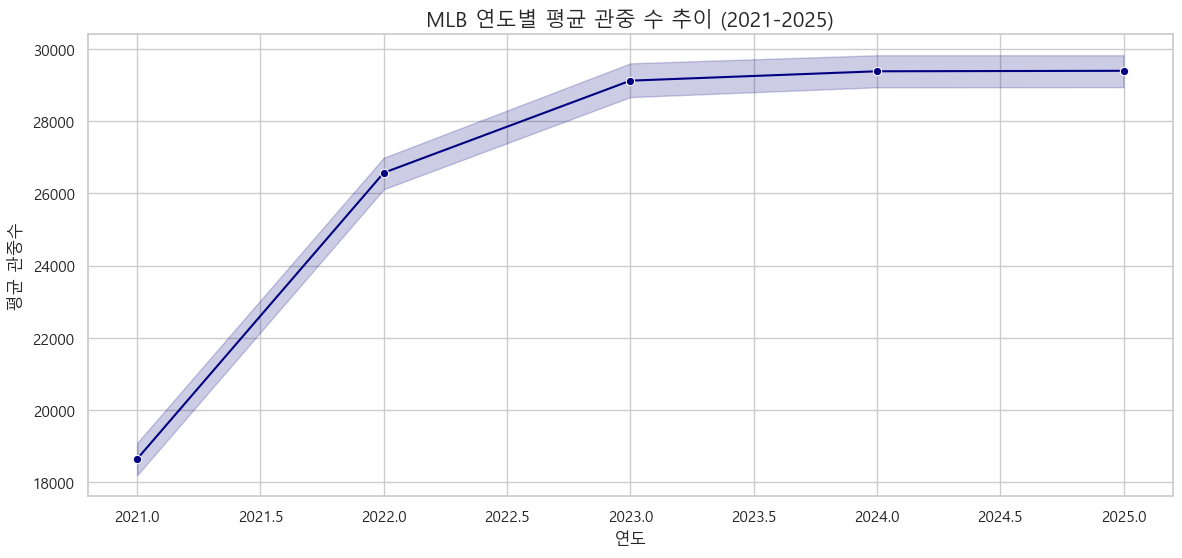

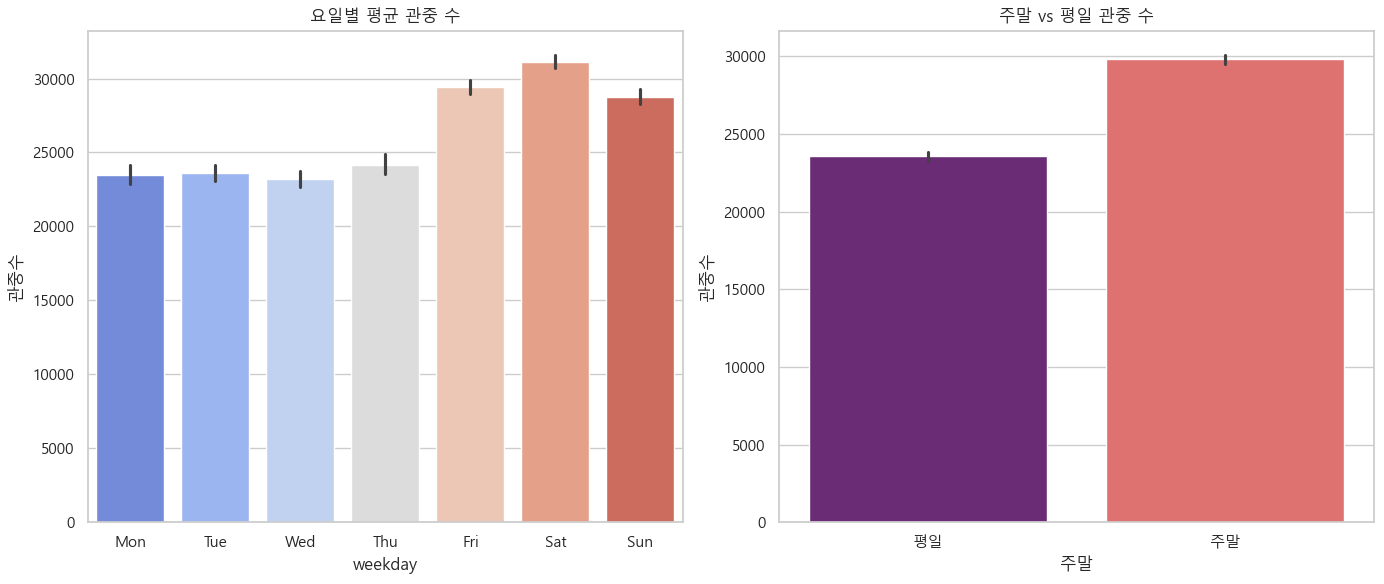

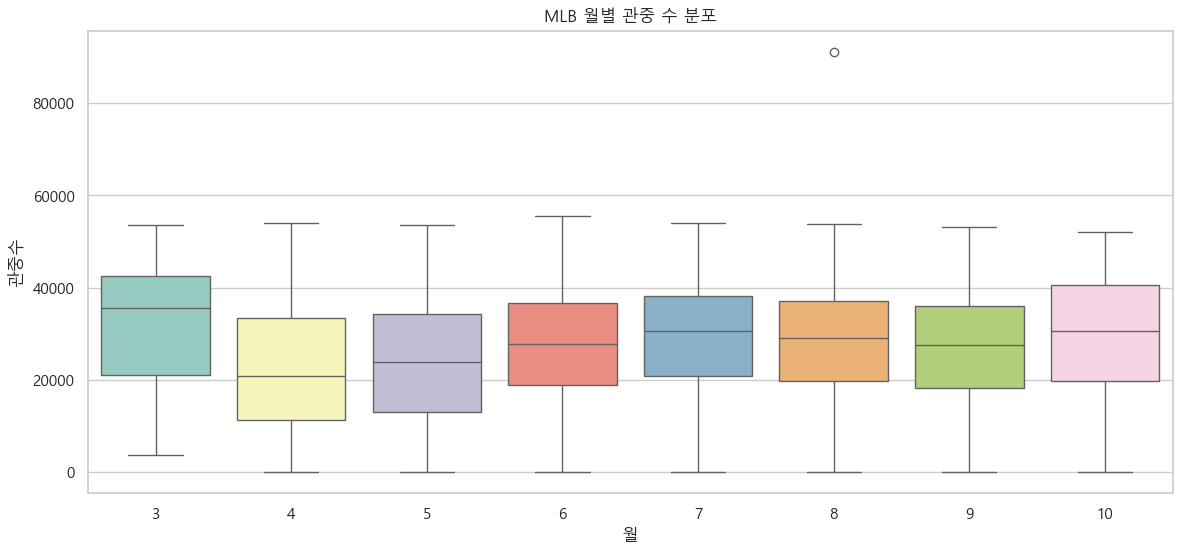

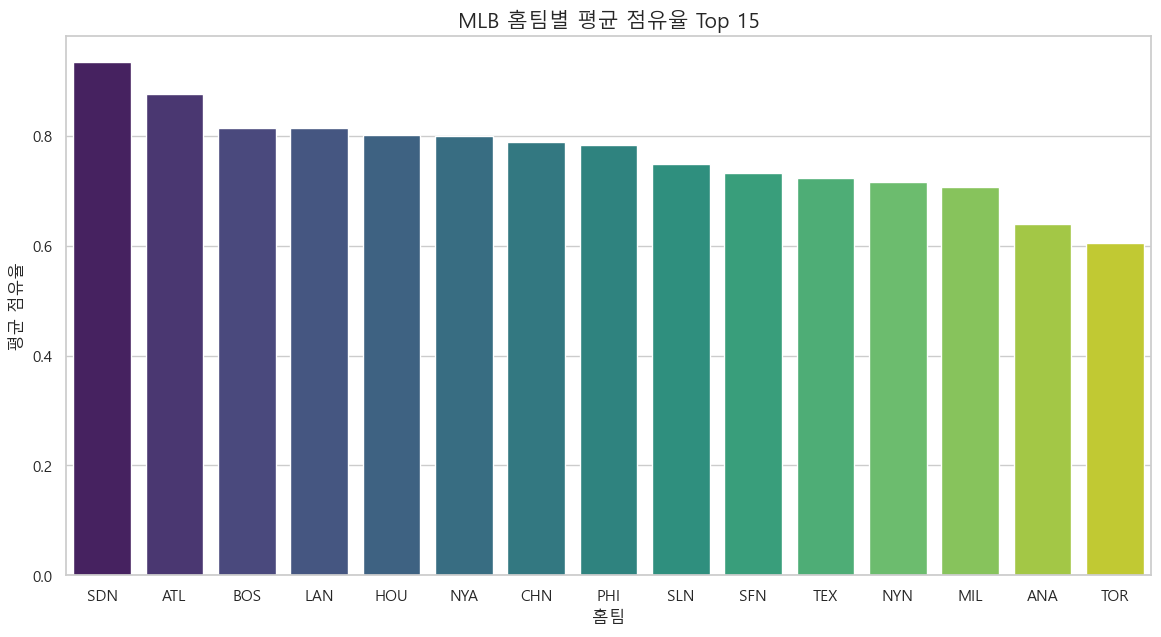

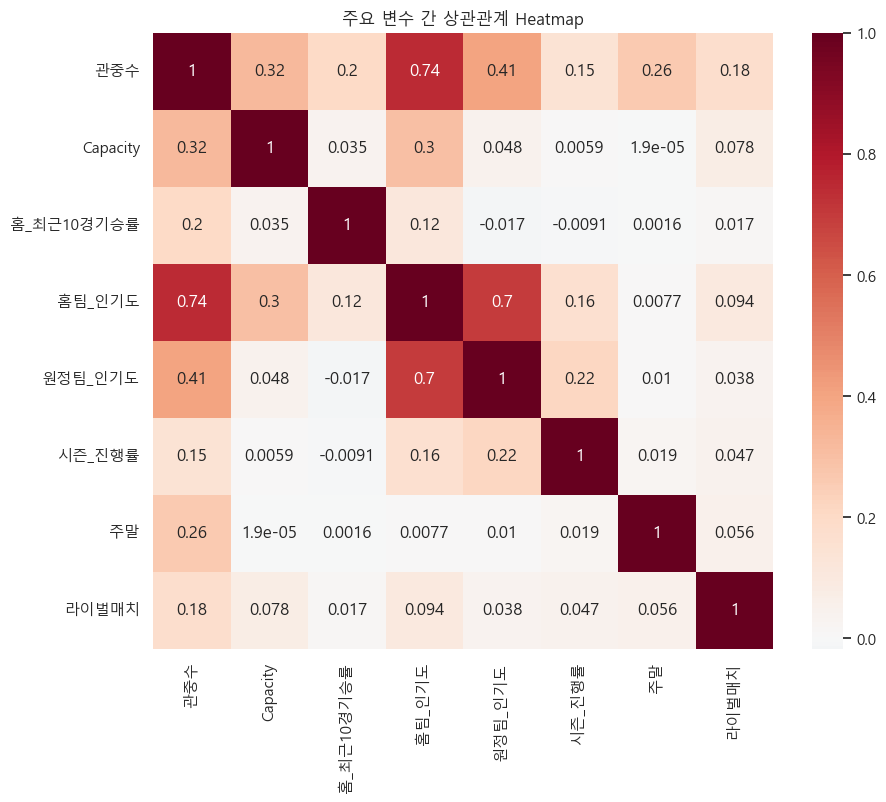

In [13]:
# 1. 연도별 관중 수 추이 (팬데믹 이후 회복세 확인)
plt.figure(figsize=(14, 6))
sns.lineplot(data=df[df['연도'] > 2020], x='연도', y='관중수', marker='o', estimator='mean', color='navy')
plt.title('MLB 연도별 평균 관중 수 추이 (2021-2025)', fontsize=15)
plt.ylabel('평균 관중수')
plt.show()

# 2. 요일 및 주말 효과
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=df[df['연도'] > 2020], x='weekday', y='관중수', palette='coolwarm')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('요일별 평균 관중 수')

plt.subplot(1, 2, 2)
sns.barplot(data=df[df['연도'] > 2020], x='주말', y='관중수', palette='magma')
plt.xticks(ticks=[0, 1], labels=['평일', '주말'])
plt.title('주말 vs 평일 관중 수')
plt.tight_layout()
plt.show()

# 3. 월별 관중 수 (여름 휴가철 및 포스트시즌 영향)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['연도'] > 2020], x='월', y='관중수', palette='Set3')
plt.title('MLB 월별 관중 수 분포')
plt.show()

# 4. 홈팀별 평균 점유율 Top 15
plt.figure(figsize=(14, 7))
team_occ = df[df['연도'] > 2020].groupby('홈팀')['점유율'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=team_occ.index, y=team_occ.values, palette='viridis')
plt.title('MLB 홈팀별 평균 점유율 Top 15', fontsize=15)
plt.ylabel('평균 점유율')
plt.show()

# 5. 상관관계 분석
plt.figure(figsize=(10, 8))
cols = ['관중수', 'Capacity', '홈_최근10경기승률', '홈팀_인기도', '원정팀_인기도', '시즌_진행률', '주말', '라이벌매치']
sns.heatmap(df[df['연도'] > 2020][cols].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('주요 변수 간 상관관계 Heatmap')
plt.show()

## 3. 모델링 및 성능 평가 (2025년 예측)

In [16]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

# 1. 단일 모델 정의
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6, random_state=42)
lgbm_model = LGBMRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6, verbose=-1, random_state=42)
cat_model = CatBoostRegressor(n_estimators=1000, learning_rate=0.03, depth=6, verbose=0, random_state=42)

# 2. Voting 앙상블 (단순 평균)
voting_model = VotingRegressor([
    ('xgb', xgb_model), ('lgbm', lgbm_model), ('cat', cat_model)
])

# 3. Stacking 앙상블 (최종 메타 모델로 Ridge 사용)
stacking_model = StackingRegressor(
    estimators=[('xgb', xgb_model), ('lgbm', lgbm_model), ('cat', cat_model)],
    final_estimator=Ridge()
)

# 모델 리스트
models = {
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model,
    'CatBoost': cat_model,
    'Voting': voting_model,
    'Stacking': stacking_model
}

# 학습 및 예측 결과 저장
results_df = pd.DataFrame({'Actual': y_test})
metrics = {}

print("🚀 5개 모델 학습 및 예측 시작...")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = np.maximum(0, model.predict(X_test)) # 음수 방지
    results_df[name] = preds
    
    # 평가 지표 계산
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    metrics[name] = [rmse, r2]
    print(f"✅ {name} 완료 (RMSE: {rmse:.2f})")

🚀 5개 모델 학습 및 예측 시작...
✅ XGBoost 완료 (RMSE: 8033.84)
✅ LightGBM 완료 (RMSE: 7069.00)
✅ CatBoost 완료 (RMSE: 7022.55)
✅ Voting 완료 (RMSE: 7202.70)
✅ Stacking 완료 (RMSE: 7130.17)


--- 2025 MLB 관중 수 예측 모델별 성능 성적표 ---


,RMSE,R2 Score
CatBoost,7022.546602,0.622217
LightGBM,7068.998194,0.617203
Stacking,7130.168759,0.610549
Voting,7202.704000,0.602585
XGBoost,8033.836075,0.505577


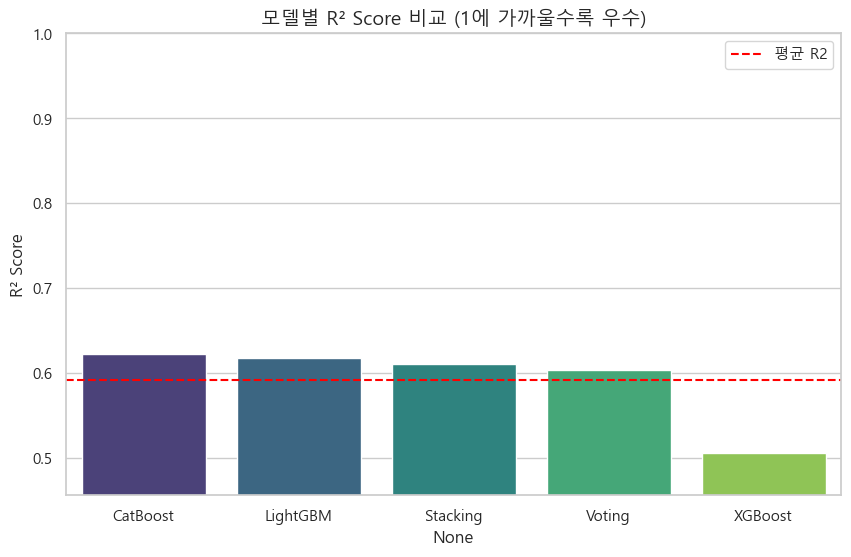

In [20]:
# 성능 지표를 데이터프레임으로 변환
metrics_df = pd.DataFrame(metrics, index=['RMSE', 'R2 Score']).T

# 점수순으로 정렬 (R2는 내림차순, RMSE는 오름차순)
metrics_df = metrics_df.sort_values(by='R2 Score', ascending=False)

print("--- 2025 MLB 관중 수 예측 모델별 성능 성적표 ---")
display(metrics_df.style.background_gradient(cmap='RdYlGn', subset=['R2 Score']))

# 시각화: R2 Score 비교
plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_df.index, y=metrics_df['R2 Score'], palette='viridis')
plt.axhline(y=metrics_df['R2 Score'].mean(), color='red', linestyle='--', label='평균 R2')
plt.title('모델별 R² Score 비교 (1에 가까울수록 우수)', fontsize=14)
plt.ylim(metrics_df['R2 Score'].min() - 0.05, 1.0) # 차이를 명확히 보기 위해 범위 조절
plt.ylabel('R² Score')
plt.legend()
plt.show()

## 4. 최종 결과 분석

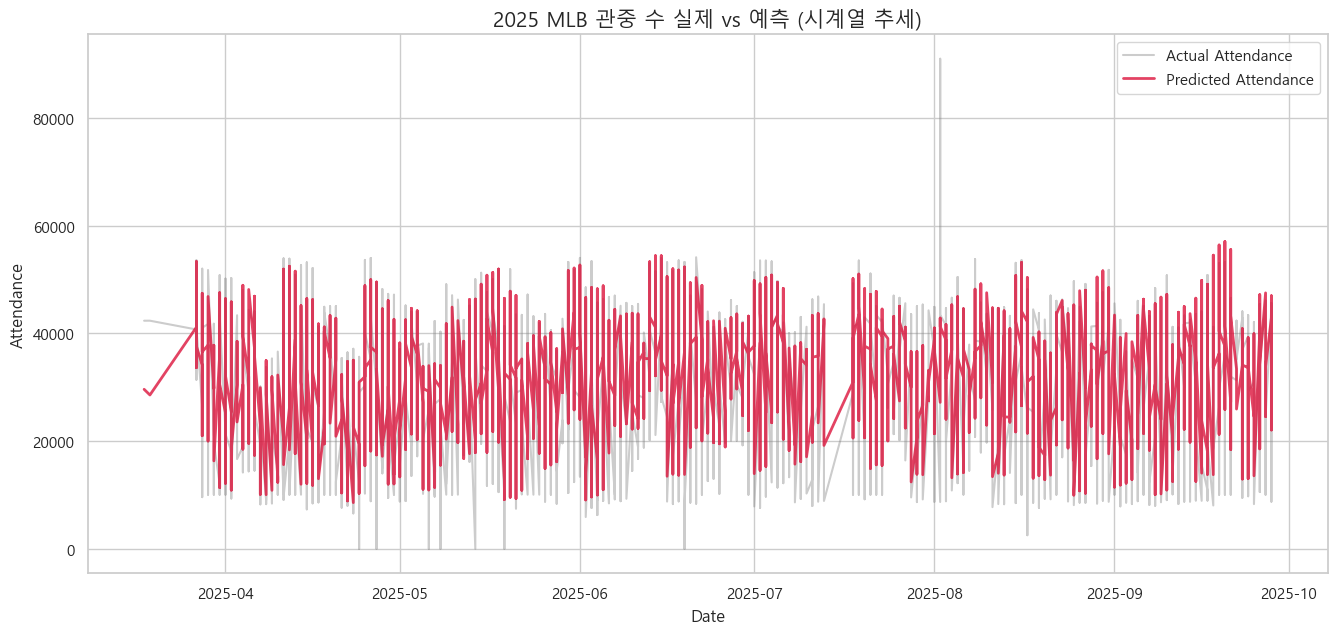

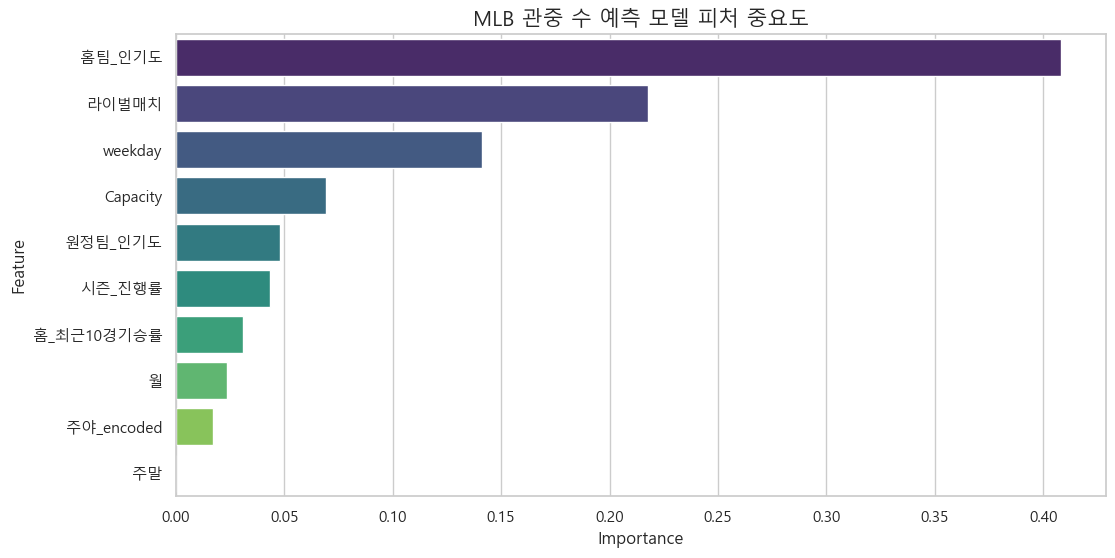

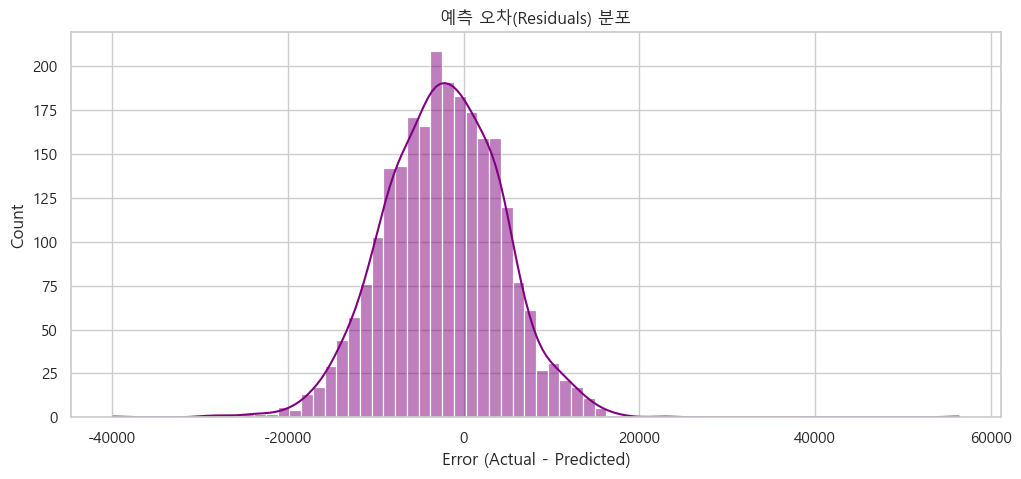

In [21]:
# 1. 실제 vs 예측 시계열 비교
plt.figure(figsize=(16, 7))
plt.plot(test_df['경기일자'], y_test, label='Actual Attendance', alpha=0.4, color='gray')
plt.plot(test_df['경기일자'], y_pred, label='Predicted Attendance', alpha=0.8, color='crimson', linewidth=2)
plt.title('2025 MLB 관중 수 실제 vs 예측 (시계열 추세)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Attendance')
plt.legend()
plt.show()

# 2. 피처 중요도 분석 (XGBoost 단일 모델 기준)
xgb_single = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
xgb_single.fit(X_train, y_train)
fi_df = pd.DataFrame({'Feature': features, 'Importance': xgb_single.feature_importances_}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('MLB 관중 수 예측 모델 피처 중요도', fontsize=15)
plt.show()

# 3. 오차 분포 확인
plt.figure(figsize=(12, 5))
sns.histplot(y_test - y_pred, kde=True, color='purple')
plt.title('예측 오차(Residuals) 분포')
plt.xlabel('Error (Actual - Predicted)')
plt.show()

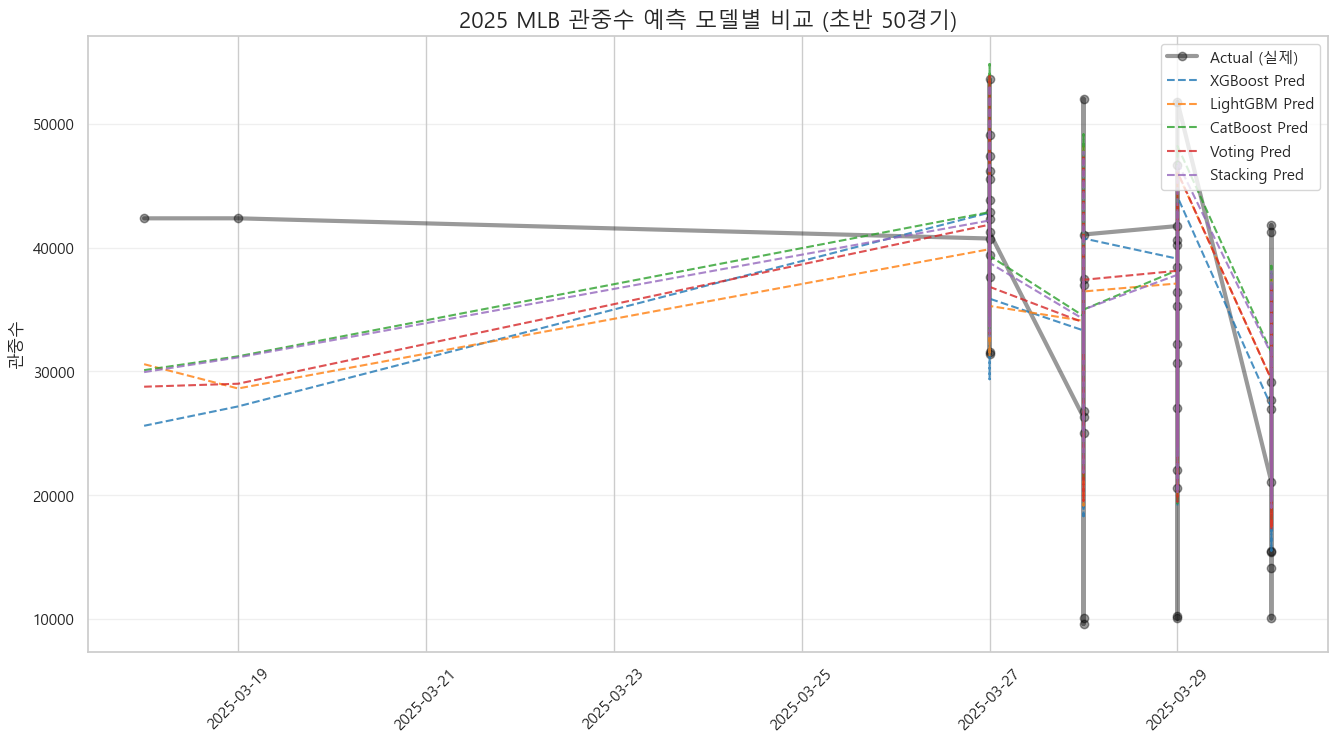

In [22]:
# 시각화를 위한 데이터 정리 (날짜 정보 포함)
plot_df = results_df.copy().head(50) # 너무 많으면 복잡하므로 50경기 추출
plot_df['Date'] = test_df['경기일자'].iloc[:50].values

plt.figure(figsize=(16, 8))
plt.plot(plot_df['Date'], plot_df['Actual'], label='Actual (실제)', color='black', linewidth=3, marker='o', alpha=0.4)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, name in enumerate(models.keys()):
    plt.plot(plot_df['Date'], plot_df[name], label=f'{name} Pred', color=colors[i], linestyle='--', alpha=0.8)

plt.title('2025 MLB 관중수 예측 모델별 비교 (초반 50경기)', fontsize=16)
plt.ylabel('관중수')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.show()